In [13]:
import analysis_tools
import importlib
import analysis_tools.beam_selection
importlib.reload(analysis_tools.beam_selection)
importlib.reload(analysis_tools)
from analysis_tools import DataLoader
from analysis_tools import BeamSelection, Cut, print_cherenkov_thresholds, SelectionMonitor

### Open the file

In [14]:
run_number = 1610
FILE = f"/eos/experiment/wcte/data/2025_commissioning/processed_offline_data/production_v1_0/{run_number}/WCTE_merged_production_R{run_number}.root"
loader = DataLoader(FILE)


In [15]:
# Check which particles are above Cherenkov threshold in each ACT for this run.
# This tells you whether the ACT-based cuts in your selection are meaningful.
# Look out for kaon runs in particular 
# Be careful, particles will have lost momentum by the time they reach the ACTs, the values indicated here are indicatve only.
vme_run_info = loader.get_vme_analysis_run_info()
print_cherenkov_thresholds(vme_run_info)

Run momentum : 760 MeV/c
n (act_eveto)  = 1.0100   n (act_tagger) = 1.0150

Particle   Mass [MeV]   Thresh. ACT eveto [MeV]  Above?   Thresh. ACT tagger [MeV]  Above?
------------------------------------------------------------------------------------------
electron        0.511                      3.6     yes                       2.9     yes
muon          105.660                    745.3     yes                     607.8     yes
pion          139.570                    984.5      no                     802.8      no
kaon          493.680                   3482.2      no                    2839.6      no
proton        938.270                   6618.0      no                    5396.9      no
deuteron     1876.540                  13236.1      no                   10793.8      no
helium3      2808.390                  19808.9      no                   16153.8      no


In [ ]:
vme_scalar_results = loader.get_vme_analysis_scalar_results()

# --- Define your particle selections ---
# Each cut is specified as [variable, operator, value].
# Known short names: "act_eveto", "act_tagger", "tof", "mu_tag_total".
# Any unrecognised name is auto-prefixed with "vme_".
# Use extra_cuts=[...] to add any number of additional cuts.

# PIONS: fast particles that do not produce Cherenkov light in either ACT.
pion_sel = BeamSelection.pion(
    ["vme_act_eveto",  "<", vme_scalar_results['act_eveto_cut']],
    ["vme_act_tagger", "<", vme_scalar_results['act_tagger_cut']],
    proton_tof_cut = vme_scalar_results['proton_tof_cut'],
)

# MUONS: fast particles, below threshold in the upstream ACT (act_eveto),
#        but ABOVE threshold in the downstream ACT (act_tagger),
#        with an additional cut on the total muon tagger signal.
muon_sel = BeamSelection.muon(
    ["vme_act_eveto",  "<", vme_scalar_results['act_eveto_cut']],
    ["vme_act_tagger", ">", vme_scalar_results['act_tagger_cut']],
    proton_tof_cut = vme_scalar_results['proton_tof_cut'],
    # Additional cut on the total muon tagger signal, only relevant at higher momentum 
    extra_cuts = [["vme_mu_tag_total", ">", vme_scalar_results['mu_tag_cut']]],
)

# ELECTRONS: fast particles that are ABOVE threshold in the upstream ACT (act_eveto).
ele_sel = BeamSelection.electron(
    ["act_eveto", ">", vme_scalar_results['act_eveto_cut']],
    proton_tof_cut = vme_scalar_results['proton_tof_cut'],
)

# PROTONS: slow particles identified by their TOF falling in a window ABOVE
#          the fast/slow separation value. Only available when proton_tof_cut > 0.
proton_sel = BeamSelection.proton(
    proton_tof_cut    = vme_scalar_results['proton_tof_cut'],
    proton_tof_window = 10,  # width of the TOF window [ns]
)

pion_sel.describe()

Selection : pion
  vme_tof_corr           < 21.1 ns  [below threshold]
  vme_act_eveto          < 7.14 PE  [below threshold]
  vme_act_tagger         < 4.44 PE  [below threshold]


### Define the PID selections based on the beam analysis information

### Loading the data in batches

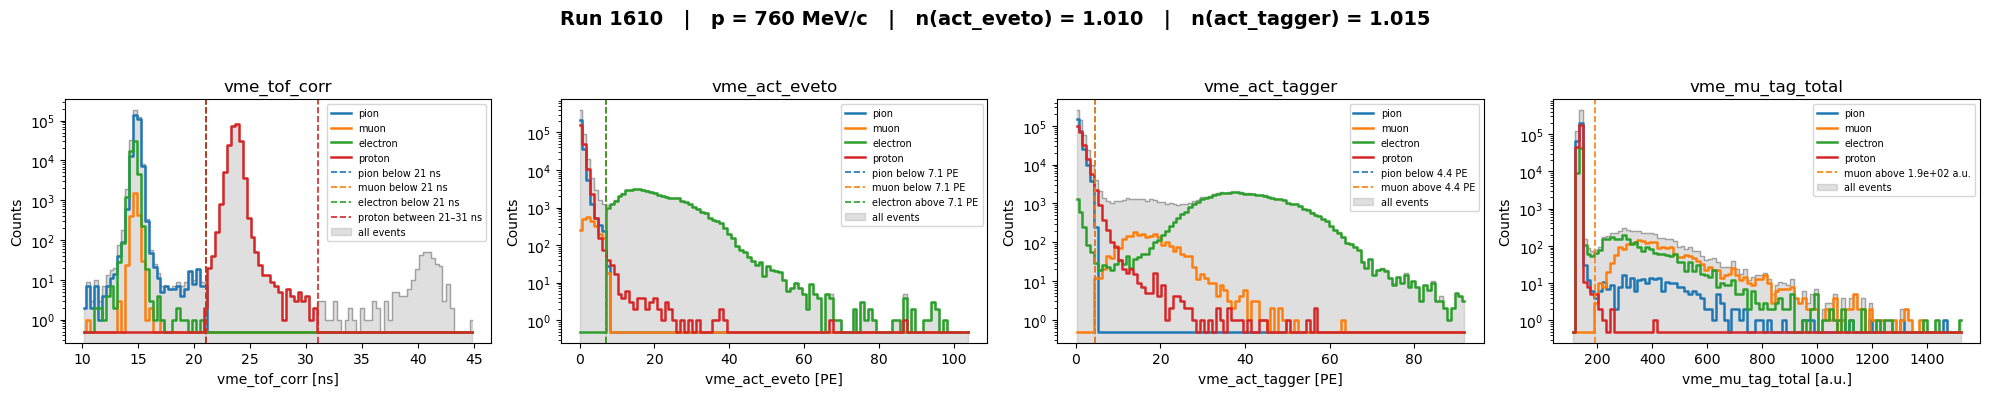

In [ ]:
import time
import awkward as ak

loader.apply_mPMT_data_quality_cuts()
loader.apply_vme_event_quality_cuts()
loader.apply_t5_event_quality_cuts()

# Enable parquet output for the selections you want to save.
# Default filename is "<particle>.parquet". Pass a path to override.
pion_sel.enable_parquet_output(f"run{run_number}_pions.parquet")
muon_sel.enable_parquet_output(f"run{run_number}_muons.parquet")
ele_sel.enable_parquet_output(f"run{run_number}_electrons.parquet")

selections = [pion_sel, muon_sel, ele_sel, proton_sel]
monitor    = SelectionMonitor(selections, update_every=10, vme_run_info=vme_run_info)

start_time = time.time()
n_windows_passing = 0

for i_batch, batch in enumerate(loader.iterate(verbose=False, step_size="100 MB")):
    n_windows_passing += len(batch)
    monitor.update(batch)
    for sel in selections:
        sel._write_to_parquet(batch[sel.mask(batch)])

for sel in selections:
    sel.close_parquet_writer()

monitor.show()
print(f"Loaded {n_windows_passing} events across {i_batch+1} batches  "
      f"({time.time() - start_time:.1f} s)")

In [6]:
# Read back the saved muon events and inspect them.
# The same pattern works for pions (pion_sel._parquet_path) and electrons.
muons = ak.from_parquet(muon_sel._parquet_path)

print(f"Total muons saved : {len(muons)}")
print(f"Mean corrected TOF: {float(ak.mean(muons['vme_tof_corr'])):.2f} ns")
print(f"Mean act_eveto    : {float(ak.mean(muons['vme_act_eveto'])):.3f} PE")
print(f"Mean act_tagger   : {float(ak.mean(muons['vme_act_tagger'])):.3f} PE")


Total muons saved : 34043
Mean corrected TOF: 14.79 ns
Mean act_eveto    : 1.740 PE
Mean act_tagger   : 15.408 PE


Get the good PMT list (by mPMT slot and pmt position). Any hit which is not from a good channel is be masked. This is useful for determining which channels are reading out stably for comparison to monte carlo.

In [7]:
#get the good PMTs slot and position
good_wcte_mpmt_slots, good_wcte_pmt_pos = loader.get_good_wcte_pmts()
print(good_wcte_mpmt_slots,good_wcte_pmt_pos)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 81, 81, 81, 81, 81, 81, 81, 81, 81, 81] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ..., 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [8]:
print("Get the configuration data from the merged file:")
config = loader.get_configuration()
print(config)

print("Get the data quality metrics from the merged file:")
dqm = loader.get_data_quality_metrics()
print(dqm)

print("Get the data quality metrics from the merged file:")
dqm = loader.get_data_quality_metrics()
print(dqm)

print("Get the vme_analysis_scalar_results from the merged file:")
vme_scalar_results = loader.get_vme_analysis_scalar_results()
print(vme_scalar_results)

print("Get the vme_analysis_scalar_results from the merged file:")
vme_run_info = loader.get_vme_analysis_run_info()
print(vme_run_info)

Get the configuration data from the merged file:
{run_configuration: 'Good_mpmt_beam_v43', good_wcte_pmts: [0, ...], ...}
Get the data quality metrics from the merged file:
{n_good_pmt_channels: 1562, n_triggers: 1136955, n_bad_triggers: 169195, ...}
Get the data quality metrics from the merged file:
{n_good_pmt_channels: 1562, n_triggers: 1136955, n_bad_triggers: 169195, ...}
Get the vme_analysis_scalar_results from the merged file:
{act_eveto_cut: 7.14, act_tagger_cut: 4.44, proton_tof_cut: 21.1, ...}
Get the vme_analysis_scalar_results from the merged file:
{run_number: 1610, run_momentum: 760, n_eveto: 1.01, n_tagger: 1.01, ...}
